# 01 — WESAD Data Exploration
**Project:** Quantum Machine Learning for Physiological Stress Classification: A Comparative Study of QSVM and VQC on WESAD  
**Author:** Kenza Qribis  

---

## Purpose
Thorough exploration of the WESAD dataset before any preprocessing or modeling. The goal is to fully understand the data structure, signal characteristics, class distributions, and label quality across all 15 subjects — informing all downstream design decisions.

## Research Context
**Primary Research Question:**  
How do QSVM and VQC compare against classical models (Logistic Regression, SVM, Random Forest) for physiological stress classification under subject-independent (LOSO) evaluation on WESAD?

**Classification Tasks:**
- **Binary (primary):** Baseline (label=1) vs. Stress (label=2)
- **3-class (optional):** Baseline vs. Stress vs. Amusement (label=3)

**Evaluation Protocol:** Leave-One-Subject-Out (LOSO) — 15 folds

**Models planned:**
- Classical: Logistic Regression, SVM (RBF kernel), Random Forest
- Quantum: QSVM (ZZFeatureMap / PauliFeatureMap), VQC (RealAmplitudes / EfficientSU2)

**Feature reduction:** PCA to 3–4 components before quantum encoding

---
> Set `WESAD_PATH` in Section 0 before running.

## 0. Configuration & Setup

In [3]:
import os
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from datetime import datetime

# ── SET THIS TO YOUR LOCAL WESAD FOLDER ──────────────────────────────────────
WESAD_PATH = r"C:/Users/ACER/Desktop/APPLIED RESEARCH/Applied-Research/data/WESAD" 
# ─────────────────────────────────────────────────────────────────────────────

# ── Results folder structure ──────────────────────────────────────────────────
RESULTS_ROOT    = os.path.join("..", "results")
PLOTS_DIR       = os.path.join(RESULTS_ROOT, "plots", "01_exploration")
LOGS_DIR        = os.path.join(RESULTS_ROOT, "logs")
OUTPUT_DATA_DIR = os.path.join(RESULTS_ROOT, "output_data")

for d in [PLOTS_DIR, LOGS_DIR, OUTPUT_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Subjects (S12 does not exist in WESAD) ────────────────────────────────────
ALL_SUBJECTS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]

# ── Label definitions ─────────────────────────────────────────────────────────
LABEL_MAP = {
    0: 'not_defined',
    1: 'baseline',
    2: 'stress',
    3: 'amusement',
    4: 'meditation'
}
BINARY_LABELS     = {1: 'baseline', 2: 'stress'}
THREE_CLASS_LABELS = {1: 'baseline', 2: 'stress', 3: 'amusement'}

LABEL_COLORS = {
    0: '#cccccc',
    1: '#4CAF50',
    2: '#F44336',
    3: '#2196F3',
    4: '#FF9800'
}

# ── Sampling rates ────────────────────────────────────────────────────────────
FS_CHEST = 700
FS_WRIST = {'ACC': 32, 'BVP': 64, 'EDA': 4, 'TEMP': 4}

# ── Windowing strategy (finalised here, applied in notebook 02) ───────────────
WINDOW_SIZE_S = 60
WINDOW_STEP_S = 30
LABEL_PURITY  = 0.80

# ── Quantum: PCA target dimensions ───────────────────────────────────────────
PCA_N_COMPONENTS = [3, 4]

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('Configuration ready.')
print(f'  WESAD path      : {WESAD_PATH}')
print(f'  Subjects        : {ALL_SUBJECTS}')
print(f'  Plots dir       : {os.path.abspath(PLOTS_DIR)}')
print(f'  Logs dir        : {os.path.abspath(LOGS_DIR)}')
print(f'  Output data dir : {os.path.abspath(OUTPUT_DATA_DIR)}')

Configuration ready.
  WESAD path      : C:/Users/ACER/Desktop/APPLIED RESEARCH/Applied-Research/data/WESAD
  Subjects        : [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
  Plots dir       : c:\Users\ACER\Desktop\APPLIED RESEARCH\Applied-Research\results\plots\01_exploration
  Logs dir        : c:\Users\ACER\Desktop\APPLIED RESEARCH\Applied-Research\results\logs
  Output data dir : c:\Users\ACER\Desktop\APPLIED RESEARCH\Applied-Research\results\output_data


## 1. Load a Single Subject

In [4]:
def load_subject(wesad_path, subject_id):
    pkl = os.path.join(wesad_path, f'S{subject_id}', f'S{subject_id}.pkl')
    if not os.path.exists(pkl):
        raise FileNotFoundError(
            f'Not found: {pkl}\n'
            f'Expected layout: WESAD/S2/S2.pkl, WESAD/S3/S3.pkl, ...')
    with open(pkl, 'rb') as f:
        return pickle.load(f, encoding='latin1')

EXPLORE_SUBJECT = 2
data  = load_subject(WESAD_PATH, EXPLORE_SUBJECT)
chest = data['signal']['chest']
wrist = data['signal']['wrist']
labels = data['label']

print(f'Loaded S{EXPLORE_SUBJECT}')
print(f'  Top-level keys : {list(data.keys())}')
print(f'  Signal keys    : {list(data["signal"].keys())}')

Loaded S2
  Top-level keys : ['signal', 'label', 'subject']
  Signal keys    : ['chest', 'wrist']


## 2. Data Structure Inspection

In [5]:
label_counts = Counter(labels)

print('=== LABELS ===')
print(f'  Shape    : {labels.shape}')
print(f'  Dtype    : {labels.dtype}')
print(f'  Duration : {len(labels)/FS_CHEST/60:.1f} min total')
print()
for lid, cnt in sorted(label_counts.items()):
    name = LABEL_MAP.get(lid, '?')
    used = '  <- USED' if lid in THREE_CLASS_LABELS else ''
    print(f'  {lid}: {name:12s}  {cnt:8,} samples  {cnt/FS_CHEST/60:5.1f} min{used}')

print()
print('=== CHEST SIGNALS — RespiBAN @ 700 Hz ===')
for k, v in chest.items():
    a = np.array(v)
    print(f'  {k:6s} shape={str(a.shape):15s} min={a.min():8.3f} max={a.max():8.3f} mean={a.mean():.3f}')

print()
print('=== WRIST SIGNALS — Empatica E4 ===')
for k, v in wrist.items():
    a  = np.array(v)
    fs = FS_WRIST.get(k, '?')
    print(f'  {k:6s} shape={str(a.shape):15s} fs={str(fs)+"Hz":7s} min={a.min():.3f} max={a.max():.3f}')

=== LABELS ===
  Shape    : (4255300,)
  Dtype    : int32
  Duration : 101.3 min total

  0: not_defined   2,142,701 samples   51.0 min
  1: baseline       800,800 samples   19.1 min  <- USED
  2: stress         430,500 samples   10.2 min  <- USED
  3: amusement      253,400 samples    6.0 min  <- USED
  4: meditation     537,599 samples   12.8 min
  6: ?               45,500 samples    1.1 min
  7: ?               44,800 samples    1.1 min

=== CHEST SIGNALS — RespiBAN @ 700 Hz ===
  ACC    shape=(4255300, 3)    min=  -1.135 max=   2.030 mean=0.066
  ECG    shape=(4255300, 1)    min=  -1.500 max=   1.499 mean=0.001
  EMG    shape=(4255300, 1)    min=  -0.415 max=   0.301 mean=-0.002
  EDA    shape=(4255300, 1)    min=   0.263 max=   7.577 mean=1.528
  Temp   shape=(4255300, 1)    min=  28.045 max=  34.370 mean=30.877
  Resp   shape=(4255300, 1)    min= -27.904 max=  27.379 mean=0.055

=== WRIST SIGNALS — Empatica E4 ===
  ACC    shape=(194528, 3)     fs=32Hz    min=-128.000 max=127.00

## 3. Label Timeline

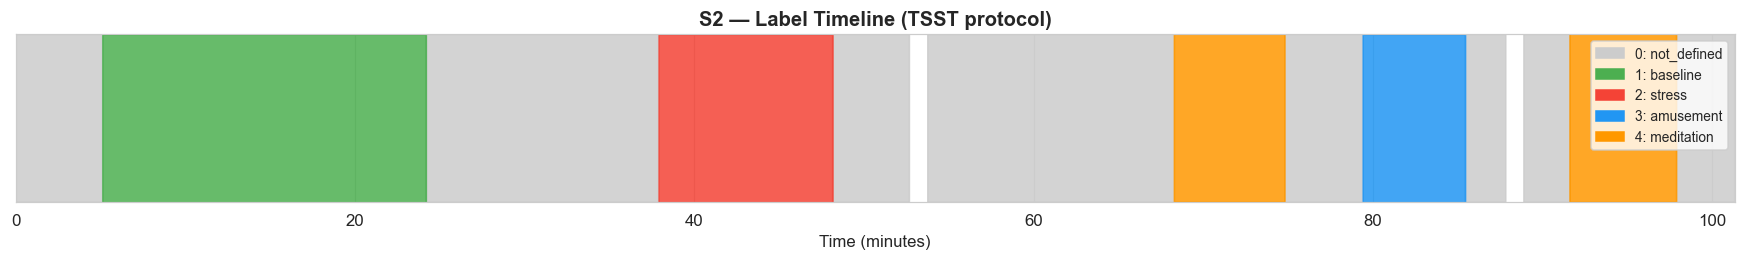

Saved: ..\results\plots\01_exploration\S2_label_timeline.png


In [6]:
fig, ax = plt.subplots(figsize=(16, 2.5))
t_min = np.arange(len(labels)) / FS_CHEST / 60

for lid, color in LABEL_COLORS.items():
    ax.fill_between(t_min, 0, 1, where=(labels == lid),
                    color=color, alpha=0.85,
                    transform=ax.get_xaxis_transform())

patches = [mpatches.Patch(color=LABEL_COLORS[k], label=f'{k}: {LABEL_MAP[k]}')
           for k in sorted(LABEL_COLORS) if k in label_counts]
ax.legend(handles=patches, loc='upper right', fontsize=9)
ax.set_xlabel('Time (minutes)')
ax.set_title(f'S{EXPLORE_SUBJECT} — Label Timeline (TSST protocol)', fontweight='bold')
ax.set_yticks([])
ax.set_xlim(0, t_min[-1])
plt.tight_layout()

p = os.path.join(PLOTS_DIR, f'S{EXPLORE_SUBJECT}_label_timeline.png')
plt.savefig(p, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

## 4. Raw Chest Signals (2-minute window)

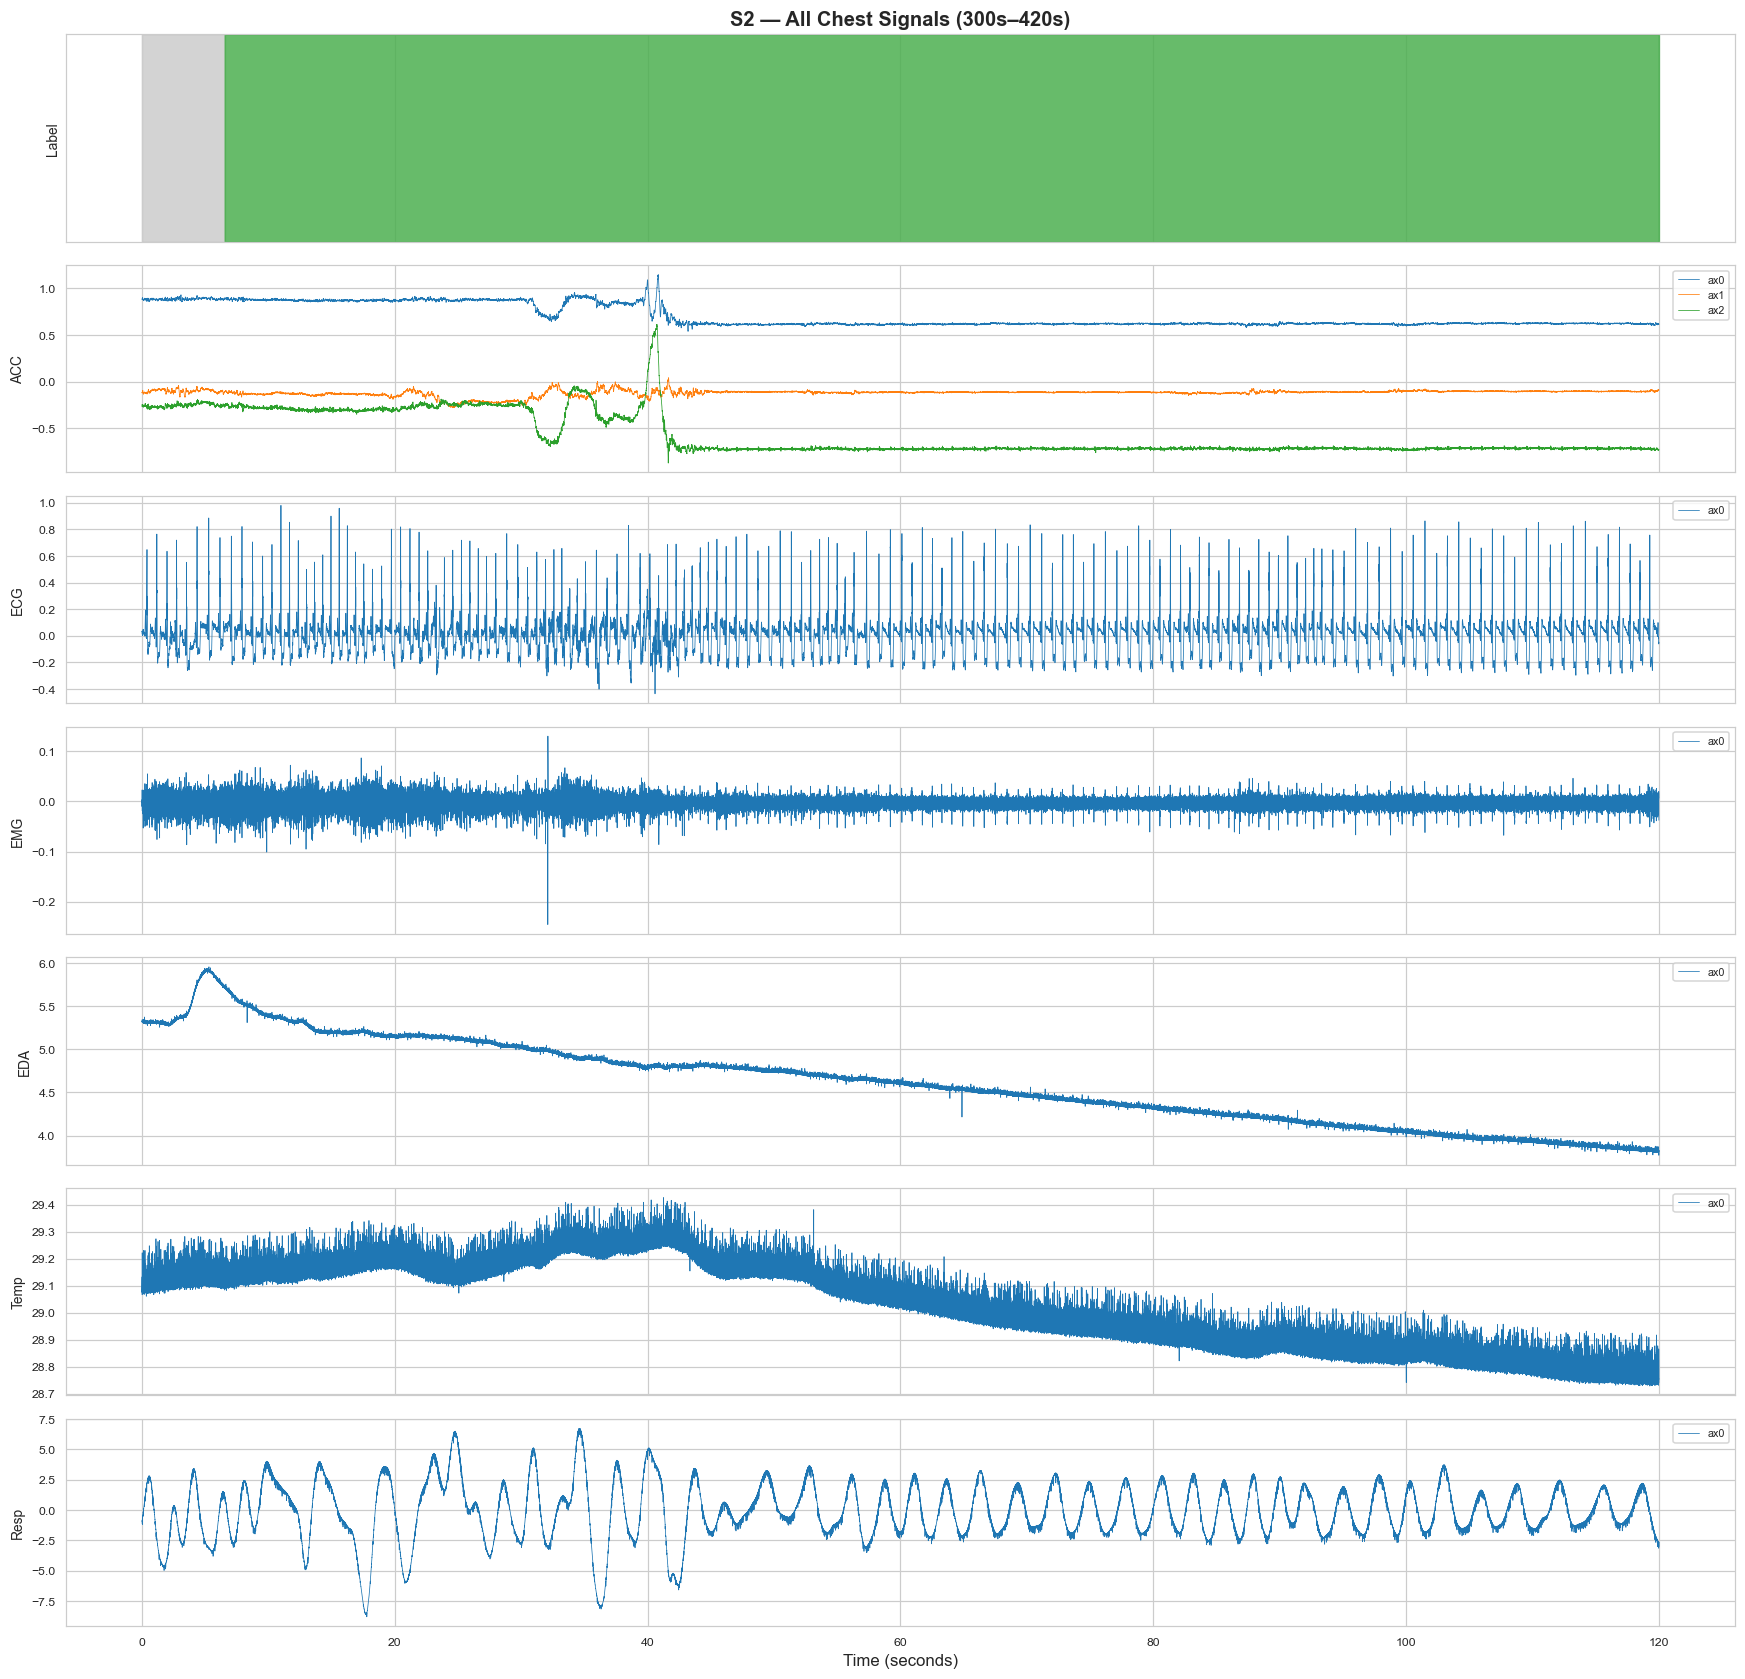

Saved: ..\results\plots\01_exploration\S2_chest_signals_raw.png


In [7]:
def plot_chest_signals(chest, labels, subject_id, duration_s=120, offset_s=300):
    signals = list(chest.keys())
    start   = offset_s * FS_CHEST
    end     = start + duration_s * FS_CHEST
    time    = np.arange(duration_s * FS_CHEST) / FS_CHEST

    fig, axes = plt.subplots(len(signals)+1, 1,
                              figsize=(16, 2.2*(len(signals)+1)), sharex=True)

    lbl_slice = labels[start:end]
    for lid, color in LABEL_COLORS.items():
        axes[0].fill_between(time, 0, 1, where=(lbl_slice==lid),
                             color=color, alpha=0.85,
                             transform=axes[0].get_xaxis_transform())
    axes[0].set_yticks([])
    axes[0].set_ylabel('Label', fontsize=9)
    axes[0].set_title(
        f'S{subject_id} — All Chest Signals ({offset_s}s–{offset_s+duration_s}s)',
        fontweight='bold')

    for i, sig_name in enumerate(signals):
        sig = np.array(chest[sig_name])[start:end]
        if sig.ndim > 1:
            for ch in range(sig.shape[1]):
                axes[i+1].plot(time, sig[:, ch], lw=0.5, label=f'ax{ch}')
            axes[i+1].legend(fontsize=7, loc='upper right')
        else:
            axes[i+1].plot(time, sig, lw=0.5, color='steelblue')
        axes[i+1].set_ylabel(sig_name, fontsize=9)
        axes[i+1].tick_params(labelsize=8)

    axes[-1].set_xlabel('Time (seconds)')
    plt.tight_layout()
    p = os.path.join(PLOTS_DIR, f'S{subject_id}_chest_signals_raw.png')
    plt.savefig(p, bbox_inches='tight')
    plt.show()
    print(f'Saved: {p}')

plot_chest_signals(chest, labels, EXPLORE_SUBJECT)

## 5. Baseline vs. Stress vs. Amusement — Direct Signal Comparison

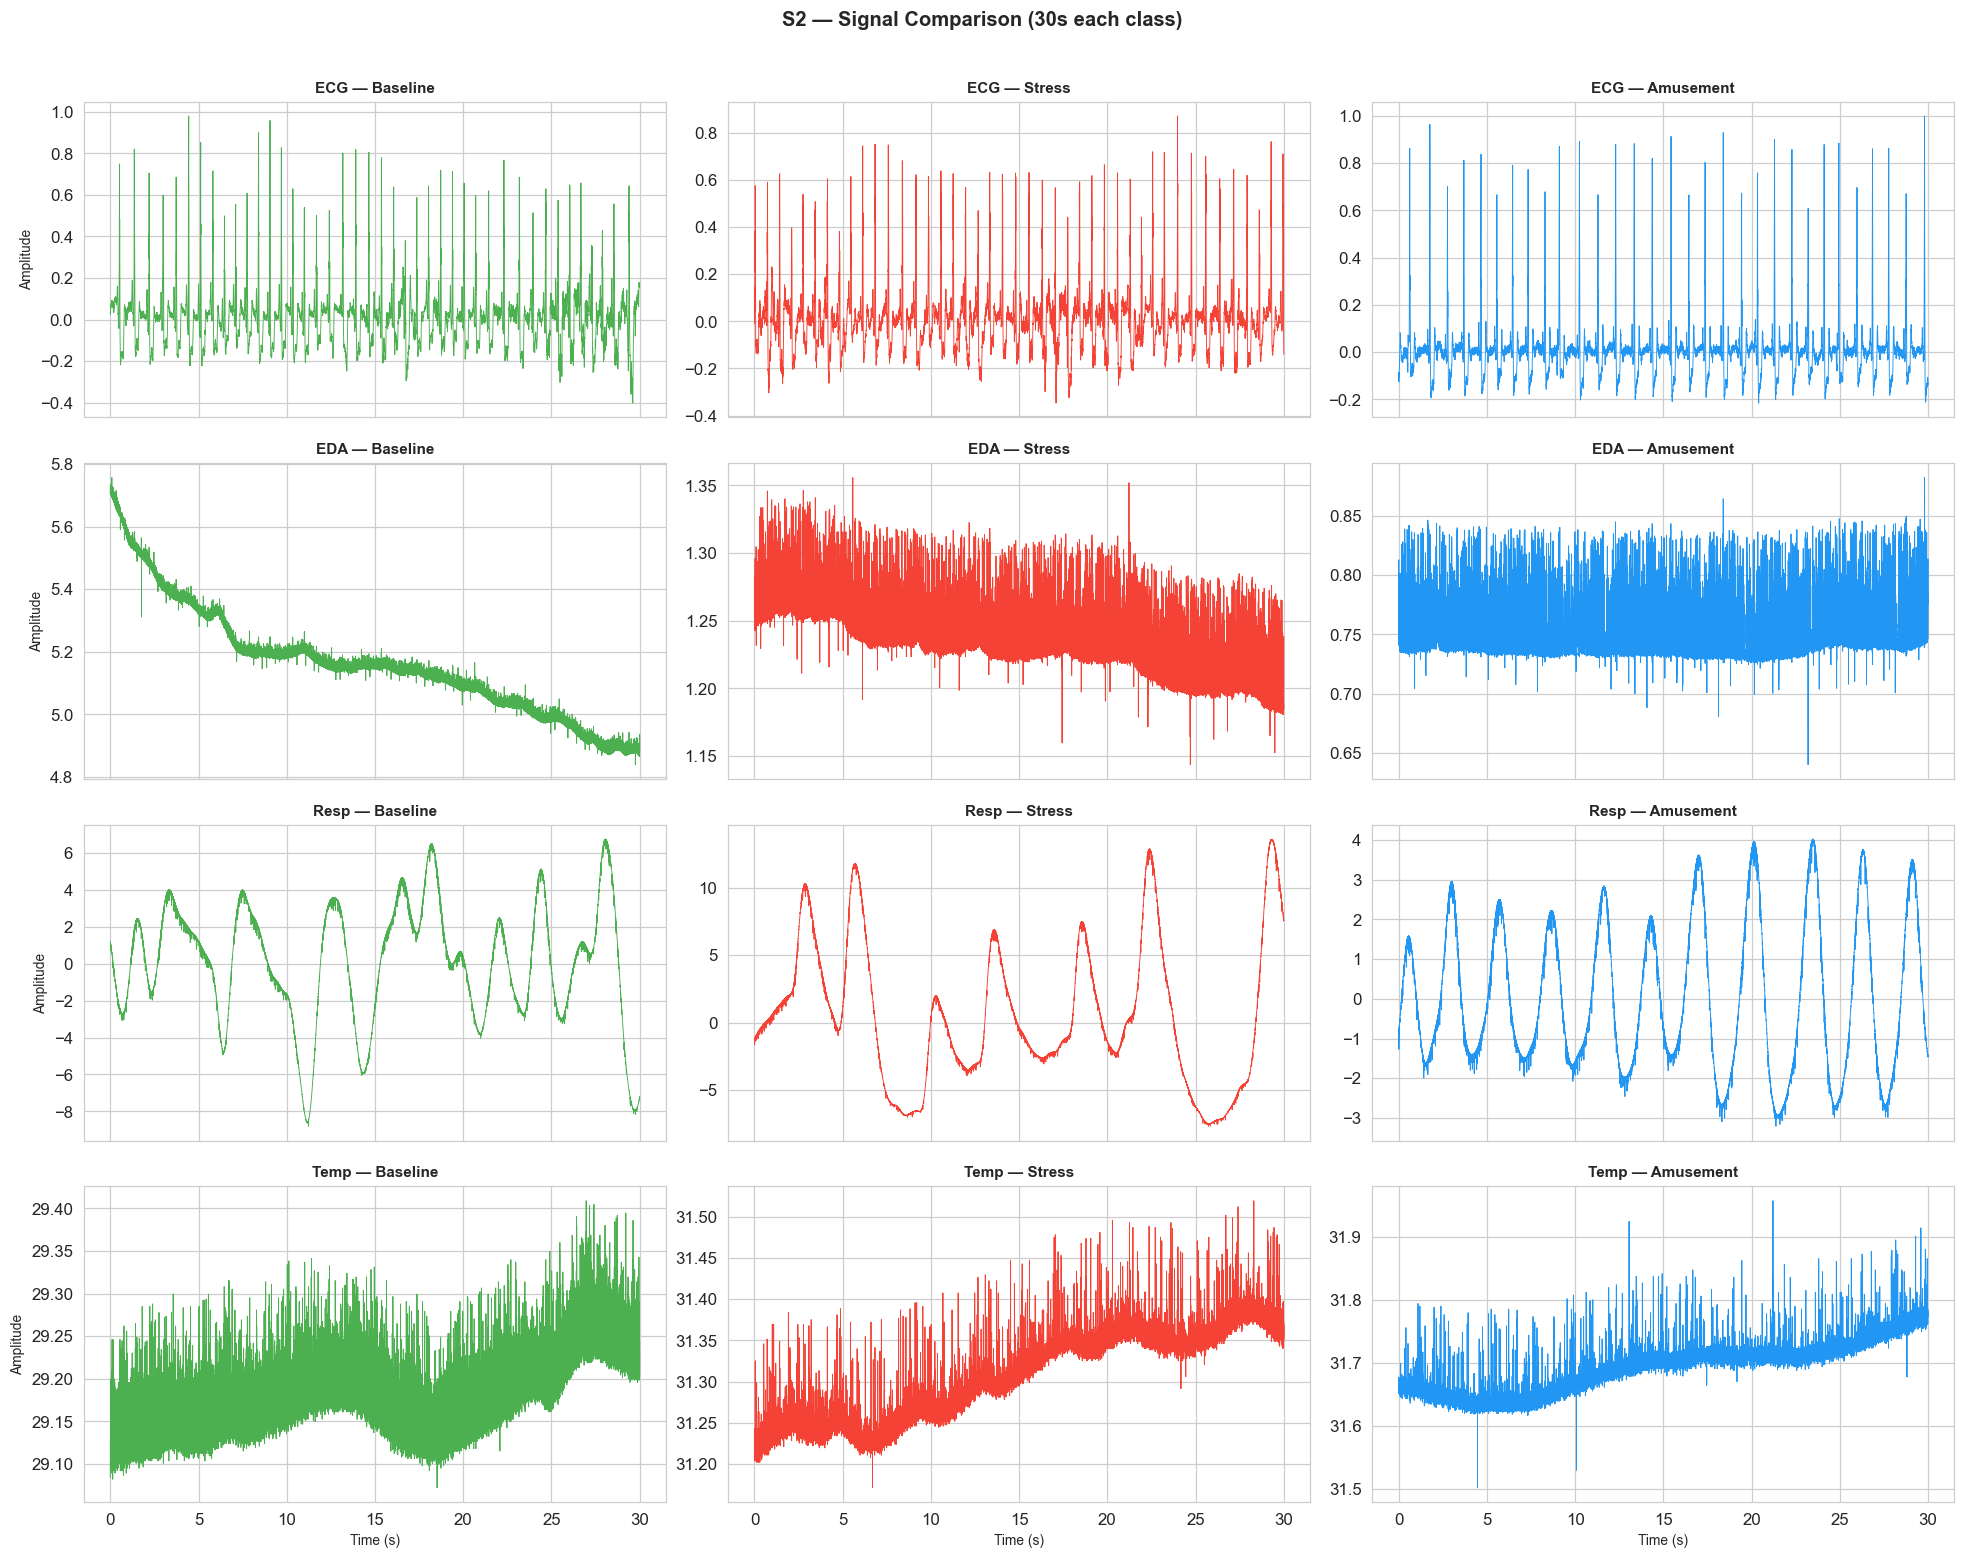

Saved: ..\results\plots\01_exploration\S2_signal_comparison_3class.png


In [8]:
def get_clean_segment(labels, signal_array, target_label, duration_s=30, fs=700):
    n = duration_s * fs
    idx = np.where(labels == target_label)[0]
    if len(idx) == 0:
        return None
    breaks = np.where(np.diff(idx) > 1)[0]
    starts = np.concatenate([[idx[0]], idx[breaks+1]])
    ends   = np.concatenate([idx[breaks], [idx[-1]]])
    for s, e in zip(starts, ends):
        if e - s >= n:
            return np.array(signal_array)[s:s+n]
    return None

compare_sigs  = [s for s in ['ECG','EDA','Resp','Temp'] if s in chest]
class_info    = [(1,'Baseline','#4CAF50'),(2,'Stress','#F44336'),(3,'Amusement','#2196F3')]
t30           = np.arange(30 * FS_CHEST) / FS_CHEST

fig, axes = plt.subplots(len(compare_sigs), 3,
                          figsize=(18, 3.5*len(compare_sigs)), sharex=True)

for row, sig_name in enumerate(compare_sigs):
    for col, (lid, lname, color) in enumerate(class_info):
        seg = get_clean_segment(labels, chest[sig_name], target_label=lid)
        ax  = axes[row][col]
        if seg is not None:
            ax.plot(t30, seg.flatten(), lw=0.6, color=color)
        ax.set_title(f'{sig_name} — {lname}', fontweight='bold', fontsize=10)
        if col == 0:
            ax.set_ylabel('Amplitude', fontsize=9)
        if row == len(compare_sigs)-1:
            ax.set_xlabel('Time (s)', fontsize=9)

plt.suptitle(f'S{EXPLORE_SUBJECT} — Signal Comparison (30s each class)',
             fontweight='bold', y=1.01)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, f'S{EXPLORE_SUBJECT}_signal_comparison_3class.png')
plt.savefig(p, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

## 6. Class Distribution Across All 15 Subjects

In [9]:
all_stats = []
for sid in ALL_SUBJECTS:
    try:
        d   = load_subject(WESAD_PATH, sid)
        cnt = Counter(d['label'])
        row = {'subject': f'S{sid}'}
        for lid, name in LABEL_MAP.items():
            row[name] = round(cnt.get(lid, 0) / FS_CHEST, 2)
        all_stats.append(row)
        total = len(d['label'])/FS_CHEST/60
        print(f'  S{sid:2d}: OK  ({total:.1f} min total)')
    except FileNotFoundError:
        print(f'  S{sid:2d}: NOT FOUND')

df_stats = pd.DataFrame(all_stats).set_index('subject')

p = os.path.join(OUTPUT_DATA_DIR, 'subject_class_durations_seconds.csv')
df_stats.to_csv(p)
print(f'\nSaved: {p}')
print(df_stats[['baseline','stress','amusement']].to_string())

  S 2: OK  (101.3 min total)
  S 3: OK  (108.2 min total)
  S 4: OK  (107.0 min total)
  S 5: OK  (104.3 min total)
  S 6: OK  (117.8 min total)
  S 7: OK  (87.3 min total)
  S 8: OK  (91.1 min total)
  S 9: OK  (87.0 min total)
  S10: OK  (91.6 min total)
  S11: OK  (87.2 min total)
  S13: OK  (92.3 min total)
  S14: OK  (92.5 min total)
  S15: OK  (87.5 min total)
  S16: OK  (93.8 min total)
  S17: OK  (98.7 min total)

Saved: ..\results\output_data\subject_class_durations_seconds.csv
         baseline  stress  amusement
subject                             
S2         1144.0   615.0      362.0
S3         1140.0   640.0      375.0
S4         1158.0   635.0      372.0
S5         1198.0   645.0      374.0
S6         1180.0   650.0      372.0
S7         1186.0   640.0      372.0
S8         1169.0   670.0      370.0
S9         1180.0   645.0      372.0
S10        1180.0   725.0      372.0
S11        1180.0   680.0      368.0
S13        1180.0   664.0      382.0
S14        1180.0   675.0  

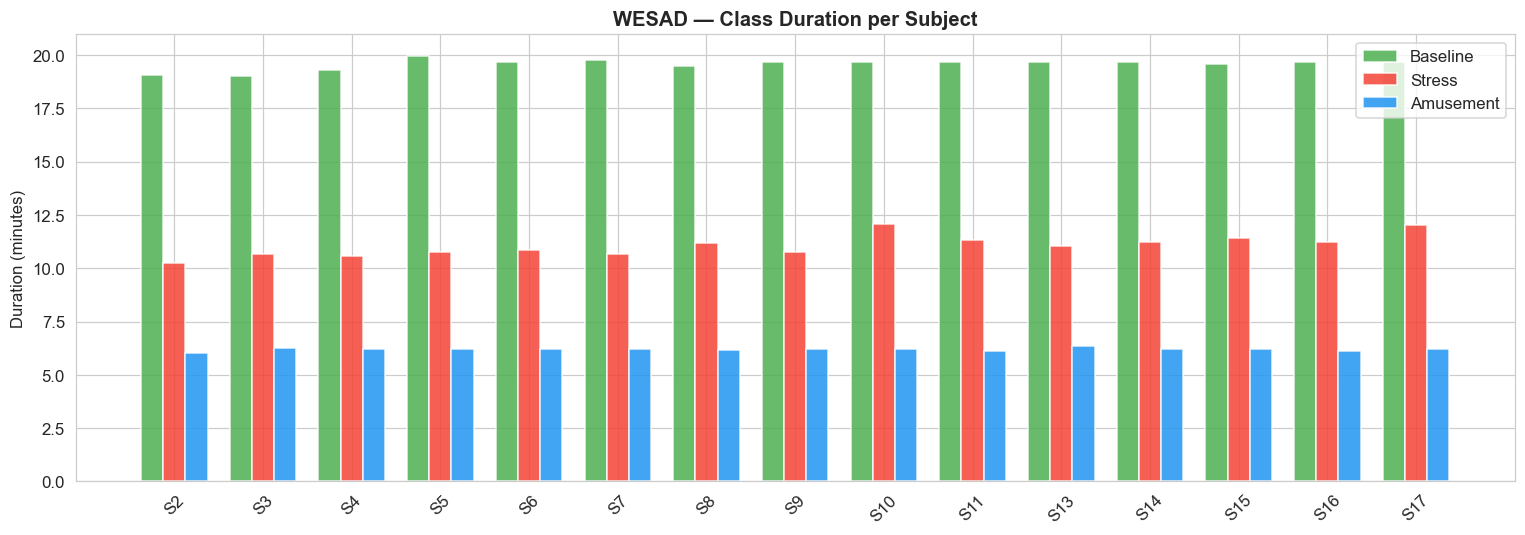

Saved: ..\results\plots\01_exploration\all_subjects_class_distribution.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
x     = np.arange(len(df_stats))
width = 0.25
for i, (cls, color) in enumerate([('baseline','#4CAF50'),
                                    ('stress',  '#F44336'),
                                    ('amusement','#2196F3')]):
    if cls in df_stats.columns:
        ax.bar(x + i*width, df_stats[cls].values/60, width,
               label=cls.capitalize(), color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(df_stats.index, rotation=45)
ax.set_ylabel('Duration (minutes)')
ax.set_title('WESAD — Class Duration per Subject', fontweight='bold')
ax.legend()
plt.tight_layout()

p = os.path.join(PLOTS_DIR, 'all_subjects_class_distribution.png')
plt.savefig(p, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

In [11]:
print('=== CLASS DURATION SUMMARY (minutes) ===')
print((df_stats[['baseline','stress','amusement']]/60).describe().round(2))

print('\n=== IMBALANCE RATIOS (relative to baseline) ===')
for cls in ['stress','amusement']:
    if cls in df_stats:
        r = df_stats[cls] / df_stats['baseline']
        print(f'  {cls}/baseline  mean={r.mean():.3f}  std={r.std():.3f}  '
              f'min={r.min():.3f}  max={r.max():.3f}')

print('\nNOTE: Class imbalance will be addressed in notebook 02 via')
print('      stratified windowing and class_weight="balanced" in classifiers.')

=== CLASS DURATION SUMMARY (minutes) ===
       baseline  stress  amusement
count     15.00   15.00      15.00
mean      19.57   11.07       6.19
std        0.26    0.52       0.07
min       19.00   10.25       6.03
25%       19.53   10.71       6.18
50%       19.67   11.07       6.20
75%       19.67   11.29       6.20
max       19.97   12.08       6.37

=== IMBALANCE RATIOS (relative to baseline) ===
  stress/baseline  mean=0.566  std=0.024  min=0.538  max=0.614
  amusement/baseline  mean=0.317  std=0.005  min=0.312  max=0.329

NOTE: Class imbalance will be addressed in notebook 02 via
      stratified windowing and class_weight="balanced" in classifiers.


## 7. Signal Statistics by Class

In [12]:
rows = []
for lid in [1, 2, 3]:
    mask = labels == lid
    for sig_name, sig_val in chest.items():
        arr = np.array(sig_val)
        if arr.ndim > 1 and arr.shape[1] > 1:
            vals  = np.linalg.norm(arr[mask], axis=1)
            dname = f'{sig_name}_mag'
        else:
            vals  = arr[mask].flatten()
            dname = sig_name
        rows.append({'signal': dname, 'label': LABEL_MAP[lid],
                     'mean': vals.mean(), 'std': vals.std(),
                     'median': np.median(vals)})

df_sig = pd.DataFrame(rows)
pivot  = df_sig.pivot(index='signal', columns='label', values='mean')
print(f'=== S{EXPLORE_SUBJECT} — Mean Signal Amplitude by Class ===')
print(pivot.round(4))

p = os.path.join(OUTPUT_DATA_DIR, f'S{EXPLORE_SUBJECT}_signal_stats_by_class.csv')
df_sig.to_csv(p, index=False)
print(f'\nSaved: {p}')

=== S2 — Mean Signal Amplitude by Class ===
label    amusement  baseline   stress
signal                               
ACC_mag     0.9265    0.9502   0.9295
ECG         0.0012    0.0012   0.0012
EDA         0.7372    2.0565   1.7969
EMG        -0.0024   -0.0025  -0.0025
Resp        0.0488    0.0384   0.0645
Temp       32.1948   28.9175  31.2184

Saved: ..\results\output_data\S2_signal_stats_by_class.csv


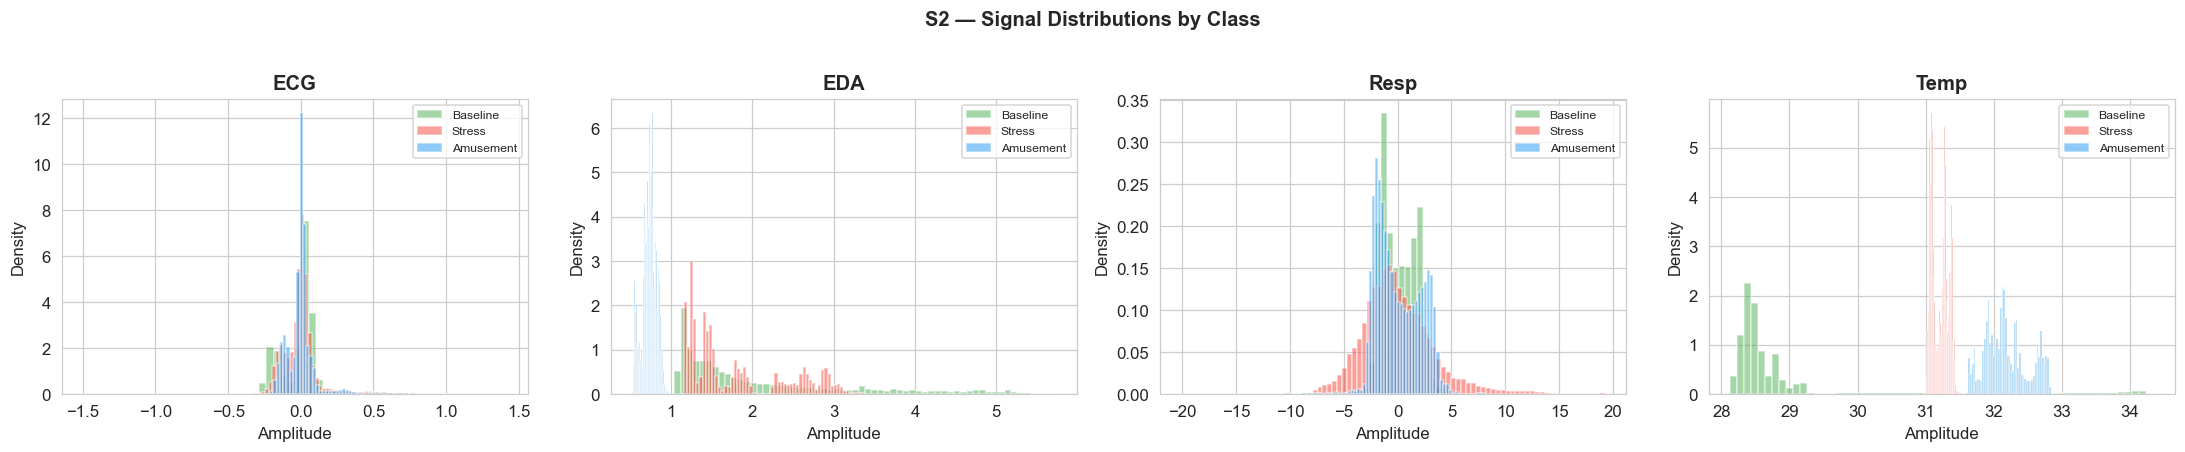

Saved: ..\results\plots\01_exploration\S2_signal_distributions.png


In [13]:
avail = [s for s in ['ECG','EDA','Resp','Temp'] if s in chest]
fig, axes = plt.subplots(1, len(avail), figsize=(5*len(avail), 4))
if len(avail) == 1:
    axes = [axes]

for ax, sig_name in zip(axes, avail):
    sig = np.array(chest[sig_name]).flatten()
    for lid, lname, color in [(1,'Baseline','#4CAF50'),
                               (2,'Stress',  '#F44336'),
                               (3,'Amusement','#2196F3')]:
        vals = sig[labels==lid][::10]
        if len(vals):
            ax.hist(vals, bins=60, alpha=0.5, color=color,
                    label=lname, density=True)
    ax.set_title(sig_name, fontweight='bold')
    ax.set_xlabel('Amplitude')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle(f'S{EXPLORE_SUBJECT} — Signal Distributions by Class',
             fontweight='bold', y=1.02)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, f'S{EXPLORE_SUBJECT}_signal_distributions.png')
plt.savefig(p, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

## 8. Data Quality Check

In [14]:
quality_log = {}
print(f'=== S{EXPLORE_SUBJECT} — NaN / Inf Check ===')
for device, signals in [('chest', chest), ('wrist', wrist)]:
    print(f'\n  {device.upper()}:')
    for sig_name, sig_val in signals.items():
        arr   = np.array(sig_val, dtype=float)
        n_nan = int(np.isnan(arr).sum())
        n_inf = int(np.isinf(arr).sum())
        status = 'OK' if (n_nan+n_inf)==0 else f'ISSUE  NaN={n_nan} Inf={n_inf}'
        print(f'    {sig_name:8s}: {status}')
        quality_log[f'{device}_{sig_name}'] = {'nan': n_nan, 'inf': n_inf}

p = os.path.join(LOGS_DIR, f'S{EXPLORE_SUBJECT}_data_quality.json')
with open(p, 'w') as f:
    json.dump(quality_log, f, indent=2)
print(f'\nSaved: {p}')

=== S2 — NaN / Inf Check ===

  CHEST:
    ACC     : OK
    ECG     : OK
    EMG     : OK
    EDA     : OK
    Temp    : OK
    Resp    : OK

  WRIST:
    ACC     : OK
    BVP     : OK
    EDA     : OK
    TEMP    : OK

Saved: ..\results\logs\S2_data_quality.json


## 9. LOSO Split Structure

In [15]:
print('=== Leave-One-Subject-Out (LOSO) Folds ===')
print(f'  {len(ALL_SUBJECTS)} subjects  →  {len(ALL_SUBJECTS)} folds')
print(f'  Each fold: train on {len(ALL_SUBJECTS)-1}, test on 1\n')

loso_log = []
for i, test_sid in enumerate(ALL_SUBJECTS):
    train = [s for s in ALL_SUBJECTS if s != test_sid]
    loso_log.append({'fold': i+1,
                     'test': f'S{test_sid}',
                     'train': [f'S{s}' for s in train]})
    print(f'  Fold {i+1:2d}: test=S{test_sid:2d}  '
          f'train={[f"S{s}" for s in train]}')

p = os.path.join(LOGS_DIR, 'loso_fold_structure.json')
with open(p, 'w') as f:
    json.dump(loso_log, f, indent=2)
print(f'\nSaved: {p}')

=== Leave-One-Subject-Out (LOSO) Folds ===
  15 subjects  →  15 folds
  Each fold: train on 14, test on 1

  Fold  1: test=S 2  train=['S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
  Fold  2: test=S 3  train=['S2', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
  Fold  3: test=S 4  train=['S2', 'S3', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
  Fold  4: test=S 5  train=['S2', 'S3', 'S4', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
  Fold  5: test=S 6  train=['S2', 'S3', 'S4', 'S5', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
  Fold  6: test=S 7  train=['S2', 'S3', 'S4', 'S5', 'S6', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
  Fold  7: test=S 8  train=['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
  Fold  8: test=S 9  train=['S2', 'S3', 'S4', 'S5', 'S6', 'S

## 10. Window Count Estimate
Estimates usable windows per subject after segmentation — informs effective dataset size before preprocessing.

In [16]:
def estimate_windows(duration_s, window_s=60, step_s=30, purity=0.80):
    raw = max(0, int((duration_s - window_s) / step_s) + 1)
    return int(raw * purity)

print(f'Window={WINDOW_SIZE_S}s  Step={WINDOW_STEP_S}s  Purity>={LABEL_PURITY*100:.0f}%\n')

win_rows = []
for _, row in df_stats.iterrows():
    wr = {'subject': row.name}
    for cls in ['baseline','stress','amusement']:
        if cls in row:
            wr[f'{cls}_windows'] = estimate_windows(
                row[cls], WINDOW_SIZE_S, WINDOW_STEP_S, LABEL_PURITY)
    win_rows.append(wr)

df_win = pd.DataFrame(win_rows).set_index('subject')
df_win['total_binary'] = (df_win.get('baseline_windows', 0)
                          + df_win.get('stress_windows', 0))
df_win['total_3class'] = (df_win['total_binary']
                          + df_win.get('amusement_windows', 0))

print(df_win.to_string())
print(f'\nTotal windows — binary task  : {df_win["total_binary"].sum()}')
print(f'Total windows — 3-class task : {df_win["total_3class"].sum()}')

p = os.path.join(OUTPUT_DATA_DIR, 'estimated_window_counts.csv')
df_win.to_csv(p)
print(f'Saved: {p}')

Window=60s  Step=30s  Purity>=80%

         baseline_windows  stress_windows  amusement_windows  total_binary  total_3class
subject                                                                                 
S2                     29              15                  8            44            52
S3                     29              16                  8            45            53
S4                     29              16                  8            45            53
S5                     30              16                  8            46            54
S6                     30              16                  8            46            54
S7                     30              16                  8            46            54
S8                     29              16                  8            45            53
S9                     30              16                  8            46            54
S10                    30              18                  8            48 

## 11. Summary Log

In [17]:
summary = {
    'notebook'        : '01_wesad_exploration',
    'timestamp'       : datetime.now().isoformat(),
    'wesad_path'      : WESAD_PATH,
    'subjects_found'  : [r['subject'] for r in all_stats],
    'subjects_missing': [f'S{s}' for s in ALL_SUBJECTS
                         if f'S{s}' not in [r['subject'] for r in all_stats]],
    'sampling_rates'  : {'chest_hz': FS_CHEST, 'wrist_hz': FS_WRIST},
    'windowing'       : {'window_s': WINDOW_SIZE_S,
                         'step_s'  : WINDOW_STEP_S,
                         'purity'  : LABEL_PURITY},
    'estimated_windows': {
        'binary_task' : int(df_win['total_binary'].sum()),
        'three_class' : int(df_win['total_3class'].sum())
    },
    'tasks': {
        'binary'     : 'baseline(1) vs stress(2)',
        'three_class': 'baseline(1) vs stress(2) vs amusement(3)'
    },
    'evaluation'  : 'Leave-One-Subject-Out (LOSO)',
    'models': {
        'classical': ['Logistic Regression','SVM (RBF)','Random Forest'],
        'quantum'  : ['QSVM (ZZFeatureMap)','QSVM (PauliFeatureMap)','VQC']
    },
    'pca_components': PCA_N_COMPONENTS,
    'next'        : '02_wesad_preprocessing.ipynb'
}

p = os.path.join(LOGS_DIR, '01_exploration_summary.json')
with open(p, 'w') as f:
    json.dump(summary, f, indent=2)

print('=' * 60)
print('EXPLORATION COMPLETE')
print('=' * 60)
print(json.dumps(summary, indent=2))
print(f'\nLog saved: {p}')

EXPLORATION COMPLETE
{
  "notebook": "01_wesad_exploration",
  "timestamp": "2026-05-09T15:39:50.048148",
  "wesad_path": "C:/Users/ACER/Desktop/APPLIED RESEARCH/Applied-Research/data/WESAD",
  "subjects_found": [
    "S2",
    "S3",
    "S4",
    "S5",
    "S6",
    "S7",
    "S8",
    "S9",
    "S10",
    "S11",
    "S13",
    "S14",
    "S15",
    "S16",
    "S17"
  ],
  "subjects_missing": [],
  "sampling_rates": {
    "chest_hz": 700,
    "wrist_hz": {
      "ACC": 32,
      "BVP": 64,
      "EDA": 4,
      "TEMP": 4
    }
  },
  "windowing": {
    "window_s": 60,
    "step_s": 30,
    "purity": 0.8
  },
  "estimated_windows": {
    "binary_task": 689,
    "three_class": 809
  },
  "tasks": {
    "binary": "baseline(1) vs stress(2)",
    "three_class": "baseline(1) vs stress(2) vs amusement(3)"
  },
  "evaluation": "Leave-One-Subject-Out (LOSO)",
  "models": {
    "classical": [
      "Logistic Regression",
      "SVM (RBF)",
      "Random Forest"
    ],
    "quantum": [
      "QS